In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time 

In [298]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [299]:
with open("../models/IF.pkl","rb") as f :
    iso=pickle.load(f)

with open("../models/AE.pkl","rb") as f :
    ae=pickle.load(f)

with open("../models/SOM.pkl","rb") as f :
    som=pickle.load(f)

In [300]:
df=pd.read_csv("../data/validation_dataset.csv")
print(df.shape)
df.head()

(1142, 21)


,TransactionID,Time,AccountNumber,CardNumber,TransactionType,Channel,TransactionAmount,MerchandGroup,Country,Country2,...,CardType,Age,Gender,Bank,City,MerchandCode,ClientID,ClientName,IsAnomaly,AnomalyType
0,MON25010081000672,2025-01-01 08:51:27,3973694259,4501140900389113,RETRAIT GAB,ATM,424.35,SUPERMARCHE,MA,MA,...,MASTERCARD_ELITE,47,FEMALE,CDM,OUJDA,SUP_OUJ_614,CLI_008,Khadija Lahlou,0,NORMAL
1,INT25010061000484,2025-01-01 10:32:03,6407369726,4062875514967525,PAIEMENT CARTE,WEB,"1,551.87",HOTEL,MA,MA,...,VISA_PREMIUM,38,FEMALE,CDM,MARRAKECH,HOT_MAR_989,CLI_006,Amina Fassi,0,NORMAL
2,MON25010011000000,2025-01-01 10:39:55,3577090037,4856403845718259,RETRAIT GAB,ATM,424.51,CAFE,MA,MA,...,MASTERCARD_ELITE,45,MALE,CDM,CASABLANCA,CAF_CAS_741,CLI_001,Hassan Benali,0,NORMAL
3,INT25010041000379,2025-01-01 10:56:00,4013818839,4119724022093700,PAIEMENT CARTE,WEB,"6,203.73",SUPERMARCHE,MA,MA,...,MASTERCARD_ELITE,51,FEMALE,CDM,FES,SUP_FES_995,CLI_004,Nadia Chraibi,1,UNUSUAL_HIGH_AMOUNT
4,MON25010101000942,2025-01-01 11:46:00,5454155475,4680020758954956,PAIEMENT CARTE,ATM,251.46,PHARMACIE,MA,MA,...,VISA_GOLD,41,FEMALE,CDM,SETTAT,PHA_SET_457,CLI_010,Souad Benkirane,1,NEW_LOCATION_DOMESTIC


In [301]:
anomalies=df.pop("AnomalyType")

In [302]:
df.drop(columns=['ClientID','ClientName'],inplace=True)

In [303]:
#TransactionID,Time,Account Number,Card Number,Transaction Type,Channel,Transaction Amount,Merchand Group,Country,Country 2,City 2,Card Type,Age,Gender,Bank,City,Merchand Code
columns=["TranasctionID","Time","Account Number","Card Number","Transaction Type","Channel","Transaction Amount","Merchand Group","Country","Country2","City2","Card Type","Age","Gender","Bank",'City','Merchand Code',"isAnomaly"]
df.columns=columns

In [304]:
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.preprocessing.PreProcessing import ClientScale,ClientNorm
from sklearn.preprocessing import MinMaxScaler

In [305]:
featureset=['Account Number','Age','LogAmount','AmountZScore','MovingAvg','MovingStd','LogTimeDiff','Hoursin','Hourcos',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']

In [306]:
globalscal=[
    'Age', 'LogAmount', 'LogTimeDiff', 
    'TransactionTypeEntropy', 'ChannelEntropy', 'CardTypeEntropy', 
    'MerchandEntropy', 'CountryEntropy', 'CityEntropy'
]

In [307]:
clientscal=['AmountZScore', 'MovingAvg', 'MovingStd',
    'TransactionTypeFreq', 'ChannelFreq', 'CardTypeFreq', 
    'MerchandFreq', 'CountryFreq', 'CityFreq']

In [308]:
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

df['Time']=pd.to_datetime(df['Time'])
df['Date']=df['Time'].dt.date
df['Hour']=df['Time'].dt.hour
df['Age']=df['Age'].astype(int)

df['Transaction Amount'] = (
    df['Transaction Amount']
    .astype(str)               
    .str.replace(',', '')      
    .astype(float)
)

In [309]:
df=ComputeTimeFeatures(df)
df=ComputeCatEntropy(df)
df=ComputeCatFreq(df)

ytrue=df['isAnomaly']
df=df[featureset]

df=ClientScale(df,'Account Number',clientscal,globalscal)

df=df.drop(columns='Account Number')

df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

In [310]:
start=time.time()

isoscore=iso.score(df)

end=time.time()
isotime=end-start
print(isotime)

0.020960569381713867


In [311]:
start=time.time()

somscore=som.score(df)

end=time.time()
somtime=end-start
print(somtime)

0.0720679759979248


In [312]:
start=time.time()

aescore=ae.score(df)

end=time.time()
aetime=end-start
print(aetime)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.23221588134765625


In [313]:
df['isoscore']=isoscore
df['aescore']=aescore
df['somscore']=somscore

In [314]:
df['isoscore'] = MinMaxScaler().fit_transform(df[['isoscore']])
df['aescore']  = MinMaxScaler().fit_transform(df[['aescore']])
df['somscore'] = MinMaxScaler().fit_transform(df[['somscore']])

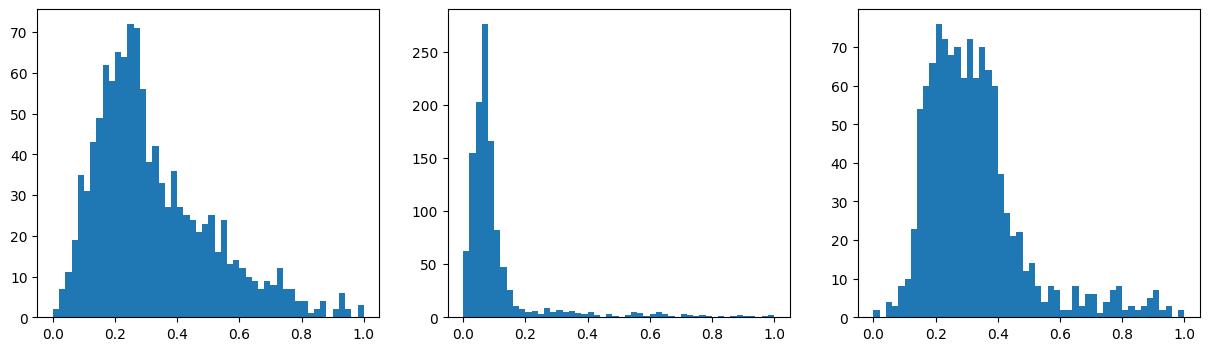

In [315]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(15,4))

axes[0].hist(df['isoscore'],bins=50)
axes[1].hist(df['aescore'],bins=50)
axes[2].hist(df['somscore'],bins=50)

plt.show()

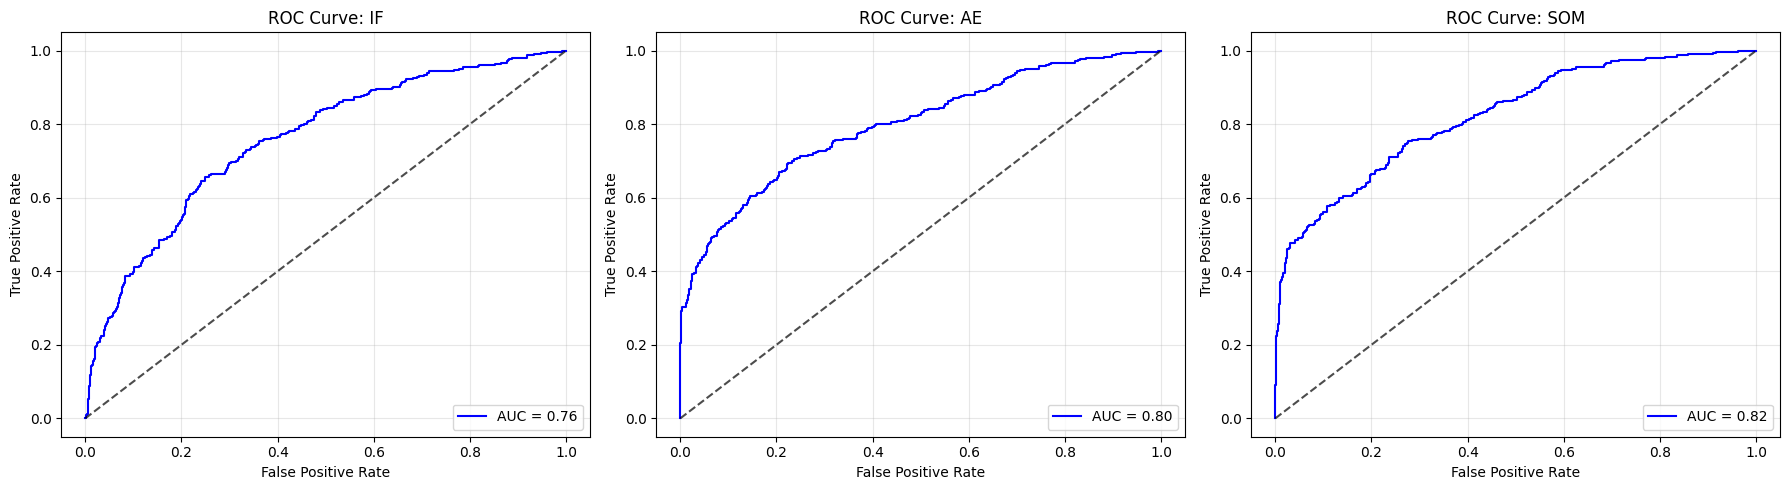

In [316]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming you have 3 sets of scores: scores1, scores2, scores3
# and their corresponding true labels: y_true1, y_true2, y_true3
models = [
    ('IF', ytrue, df['isoscore']),
    ('AE', ytrue, df['aescore']),
    ('SOM', ytrue, df['somscore'])
]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_true, scores) in enumerate(models):
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)
    
    # Plot on the specific subplot axis
    axes[i].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='blue')
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.7)  # Random baseline
    
    # Formatting each subplot
    axes[i].set_title(f'ROC Curve: {name}')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

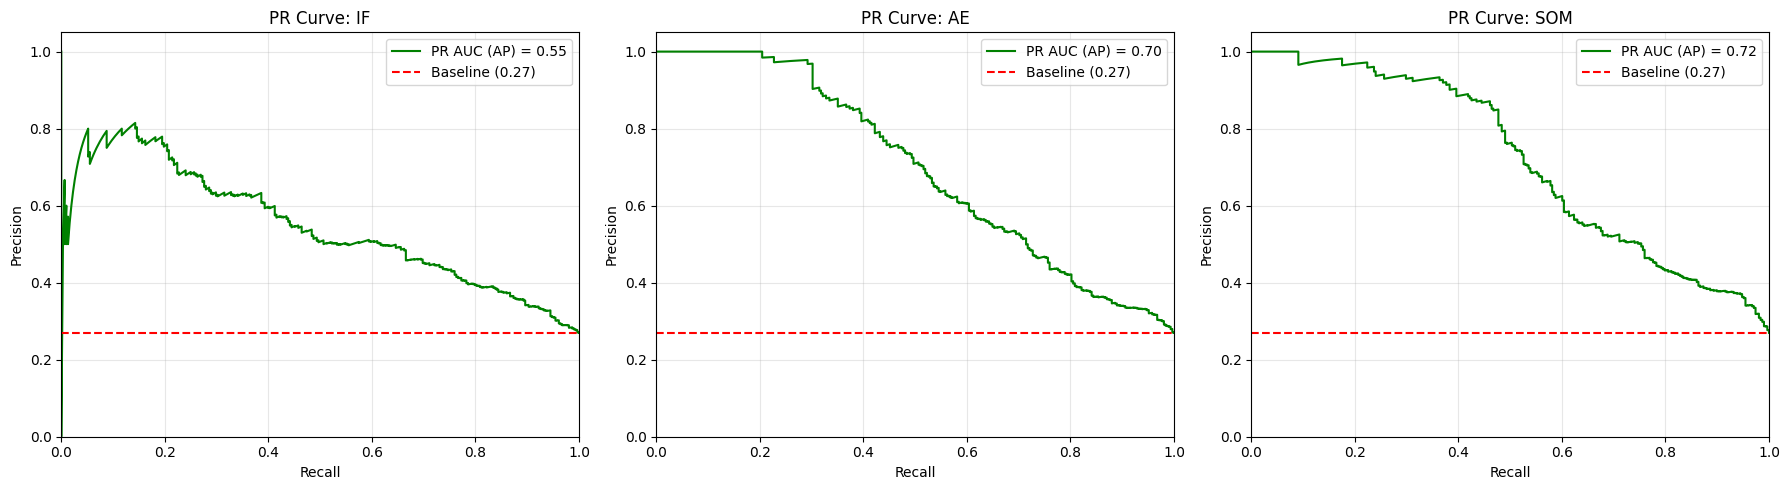

In [317]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Data structure for your 3 models
models = [
    ('IF', ytrue, df['isoscore']),
    ('AE', ytrue, df['aescore']),
    ('SOM', ytrue, df['somscore'])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_true, scores) in enumerate(models):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)
    
    # Plotting
    axes[i].plot(recall, precision, color='green', label=f'PR AUC (AP) = {pr_auc:.2f}')
    
    # Baseline for PR is the ratio of positive samples
    baseline = sum(y_true) / len(y_true)
    axes[i].axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
    
    axes[i].set_title(f'PR Curve: {name}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3)
    axes[i].set_ylim([0, 1.05])
    axes[i].set_xlim([0, 1.0])

plt.tight_layout()
plt.show()

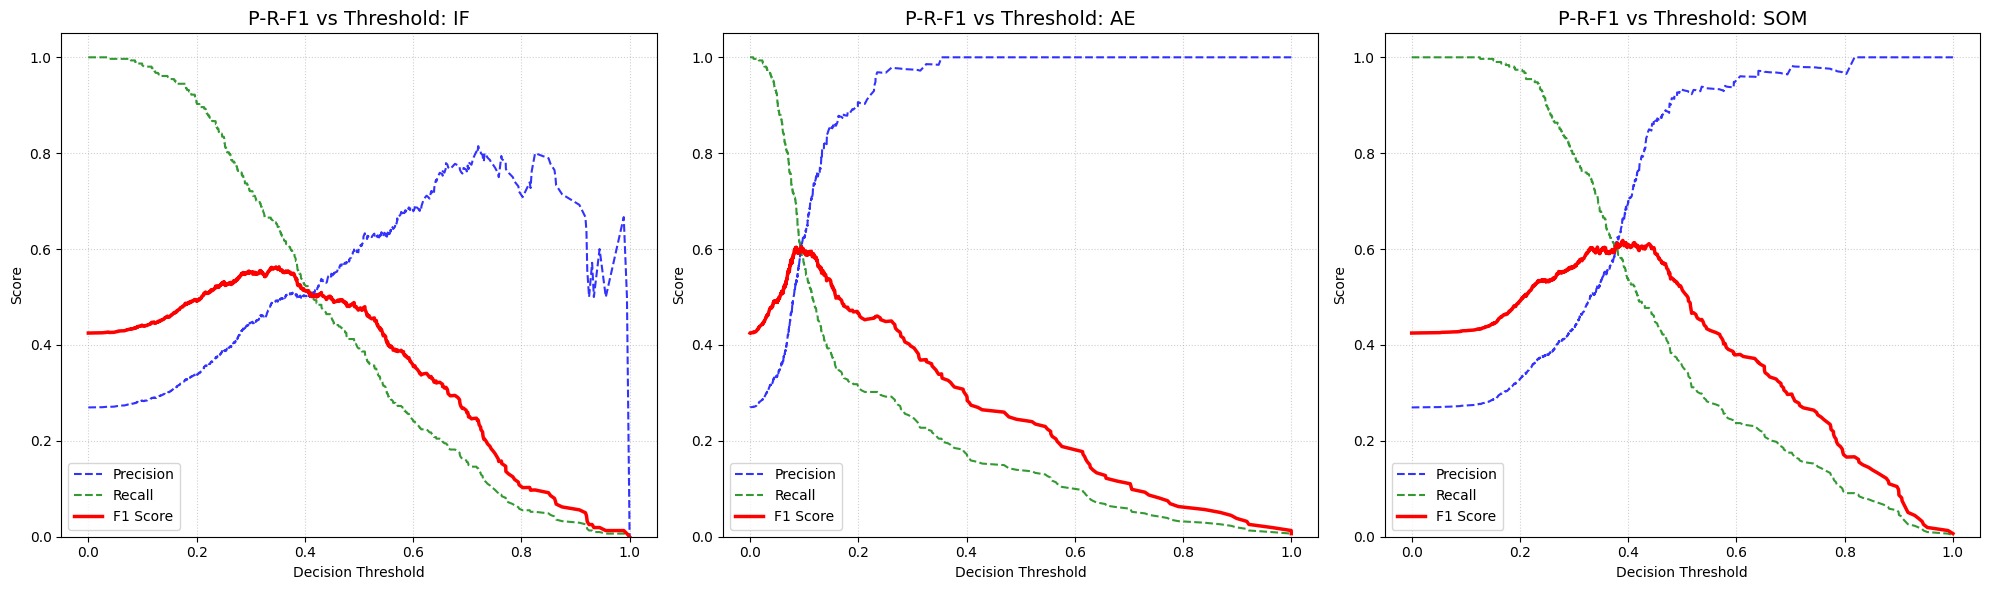

In [318]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Assuming 3 models with labels: name, y_true, scores
models = [
    ('IF', ytrue, df['isoscore']),
    ('AE', ytrue, df['aescore']),
    ('SOM', ytrue, df['somscore'])
]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, y_true, scores) in enumerate(models):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    
    # Calculate F1 score for each threshold
    # Note: precision and recall have one more element than thresholds
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Plotting on axes[i]
    axes[i].plot(thresholds, precision[:-1], 'b--', label='Precision', alpha=0.8)
    axes[i].plot(thresholds, recall[:-1], 'g--', label='Recall', alpha=0.8)
    axes[i].plot(thresholds, f1_scores[:-1], 'r-', label='F1 Score', linewidth=2.5)
    
    # Labeling and aesthetics
    axes[i].set_title(f'P-R-F1 vs Threshold: {name}', fontsize=14)
    axes[i].set_xlabel('Decision Threshold')
    axes[i].set_ylabel('Score')
    axes[i].set_ylim([0, 1.05])
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='lower left')

plt.tight_layout()
plt.show()

In [319]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support

def optimize_ensemble(y_true, scores_if, scores_ae, scores_som, step=0.05):
    best_f1 = 0
    best_results = {}
    
    # Generate weights that sum to 1
    # We use a step of 0.05 (5%) for a good balance between precision and speed
    print(f"Starting grid search with step size: {step}...")
    
    for w_if in np.arange(0, 1 + step, step):
        for w_ae in np.arange(0, 1 - w_if + step, step):
            w_som = 1.0 - w_if - w_ae
            
            # Guard against precision errors in floating point
            if w_som < -1e-9: continue 
            
            # Calculate ensemble score
            ensemble_score = (w_if * scores_if) + (w_ae * scores_ae) + (w_som * scores_som)
            
            # Metrics
            roc_auc = roc_auc_score(y_true, ensemble_score)
            pr_auc = average_precision_score(y_true, ensemble_score)
            
            # To get F1, we need to pick a threshold. 
            # Here we assume the threshold is the 95th percentile (standard for anomaly detection)
            # or you can optimize the threshold here as well.
            threshold = np.percentile(ensemble_score, 95)
            preds = (ensemble_score > threshold).astype(int)
            precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average='binary')

            if f1 > best_f1:
                best_f1 = f1
                best_results = {
                    'weights': (round(w_if, 2), round(w_ae, 2), round(w_som, 2)),
                    'roc_auc': roc_auc,
                    'pr_auc': pr_auc,
                    'precision': precision,
                    'recall': recall,
                    'f1': f1
                }

    return best_results

# Example Usage:
# results = optimize_ensemble(y_test, if_scores, ae_scores, som_scores)
# print(f"Best Weights (IF, AE, SOM): {results['weights']}")
# print(f"Best PR AUC: {results['pr_auc']:.4f}")

In [320]:
weights=optimize_ensemble(ytrue,df['isoscore'],df['aescore'],df['somscore'],step=0.05)
weights

Starting grid search with step size: 0.05...


{'weights': (np.float64(0.0), np.float64(0.35), np.float64(0.65)),
 'roc_auc': 0.8248037933289734,
 'pr_auc': 0.7300162373678409,
 'precision': 1.0,
 'recall': 0.18831168831168832,
 'f1': 0.31693989071038253}

In [321]:
df['ensemble']=0.65*df['somscore']+0.35*df['aescore']+0*df['isoscore']

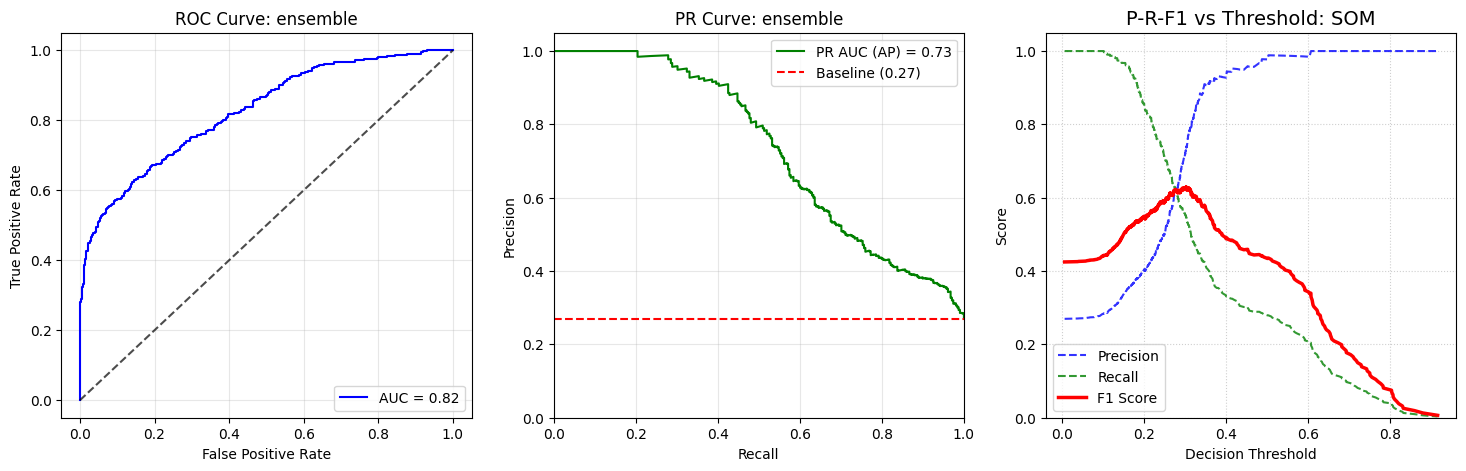

In [322]:
fig,axes=plt.subplots(1,3,figsize=(18,5))

fpr,tpr,_=roc_curve(ytrue,df['ensemble'])
roc_auc=roc_auc_score(ytrue,df['ensemble'])

#ROC AUC
axes[0].plot(fpr,tpr,label=f'AUC = {roc_auc:.2f}', color='blue')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.7)  # Random baseline
    
# Formatting each subplot
axes[0].set_title(f'ROC Curve: ensemble')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

#PR AUC
precision,recall,_=precision_recall_curve(ytrue,df['ensemble'])
pr_auc=average_precision_score(ytrue,df['ensemble'])

axes[1].plot(recall, precision, color='green', label=f'PR AUC (AP) = {pr_auc:.2f}')
    
# Baseline for PR is the ratio of positive samples
baseline = sum(y_true) / len(y_true)
axes[1].axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
    
axes[1].set_title(f'PR Curve: ensemble')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])
axes[1].set_xlim([0, 1.0])

#Precision, Recall, F1
precision, recall, thresholds = precision_recall_curve(ytrue, df['ensemble'])
    
# Calculate F1 score for each threshold
# Note: precision and recall have one more element than thresholds
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
# Plotting on axes[i]
axes[2].plot(thresholds, precision[:-1], 'b--', label='Precision', alpha=0.8)
axes[2].plot(thresholds, recall[:-1], 'g--', label='Recall', alpha=0.8)
axes[2].plot(thresholds, f1_scores[:-1], 'r-', label='F1 Score', linewidth=2.5)
    
# Labeling and aesthetics
axes[2].set_title(f'P-R-F1 vs Threshold: {name}', fontsize=14)
axes[2].set_xlabel('Decision Threshold')
axes[2].set_ylabel('Score')
axes[2].set_ylim([0, 1.05])
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend(loc='lower left')

plt.show()

In [323]:
df.insert(0,'AnomalyType',anomalies)

In [324]:
df.sort_values(by='isoscore',ascending=False).head(30)

,AnomalyType,Age,LogAmount,AmountZScore,MovingAvg,MovingStd,LogTimeDiff,Hoursin,Hourcos,TransactionTypeEntropy,...,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq,isoscore,aescore,somscore,ensemble
93,NORMAL,0.583776,0.090323,0.000000,0.000000,0.000000,0.000000,8.660254e-01,-5.000000e-01,0.814370,...,3.928434,5.392973,0.0,5.961474,0.459459,0.496729,1.000000,0.117292,0.517315,0.377307
320,NORMAL,-1.152587,-0.225412,-0.052518,1.351992,0.906497,-1.485546,5.000000e-01,-8.660254e-01,0.631204,...,-1.900655,0.163884,0.0,-2.573706,-4.491480,-3.444415,0.995104,0.366018,0.779376,0.634701
349,NORMAL,-1.152587,0.252489,0.684712,0.685148,0.711125,-1.207597,-1.000000e+00,-1.836970e-16,0.631204,...,-1.910004,0.206736,0.0,-2.667999,-4.396938,-3.368241,0.989162,0.343631,0.715517,0.585357
849,NORMAL,1.771814,-1.306905,0.000000,0.000000,0.000000,0.000000,1.224647e-16,-1.000000e+00,0.927983,...,2.054991,4.067134,0.0,5.816231,0.285843,0.458946,0.956042,0.141667,0.694222,0.500828
347,NORMAL,-1.152587,0.875644,1.600937,0.189876,0.590354,-0.323328,-8.660254e-01,5.000000e-01,0.631204,...,-1.957049,0.198208,0.0,-2.664116,-4.543026,-3.485946,0.944534,0.377405,0.767229,0.630790
383,NORMAL,-1.518138,-1.871476,0.000000,0.000000,0.000000,0.000000,-9.659258e-01,-2.588190e-01,0.945806,...,2.373754,4.870580,0.0,4.364380,0.679246,0.705046,0.933978,0.100425,0.475783,0.344408
1127,NORMAL,-0.695650,2.142616,0.730299,1.278094,2.657730,-1.080671,1.224647e-16,-1.000000e+00,-0.962569,...,-3.920057,-0.625188,0.0,-2.222117,-4.018190,-3.182924,0.930758,0.373882,0.952747,0.750144
1,NORMAL,0.401001,-0.170925,0.000000,0.000000,0.000000,0.102867,-8.660254e-01,5.000000e-01,1.031547,...,3.159952,3.039598,0.0,4.249019,0.502395,0.686163,0.925117,0.072301,0.576305,0.399904
757,NORMAL,0.035451,-0.448496,0.000000,0.000000,0.000000,0.000000,2.588190e-01,-9.659258e-01,0.743219,...,3.382949,4.293129,0.0,4.050589,0.238608,0.531027,0.921782,0.076277,0.581244,0.404506
364,NORMAL,-1.152587,-1.945329,-0.918835,0.540550,2.963001,-6.549105,-8.660254e-01,-5.000000e-01,0.631204,...,-1.299451,0.257751,0.0,-0.127191,0.192446,0.182257,0.920934,0.335442,0.943052,0.730389


In [325]:
df.sort_values(by='aescore',ascending=False).head(30)

,AnomalyType,Age,LogAmount,AmountZScore,MovingAvg,MovingStd,LogTimeDiff,Hoursin,Hourcos,TransactionTypeEntropy,...,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq,isoscore,aescore,somscore,ensemble
854,NORMAL,1.771814,-0.144649,0.000000,0.000000,0.000000,0.532466,-8.660254e-01,5.000000e-01,0.927983,...,1.321730,-0.034384,0.0,1.428747,0.285843,-3.277228,0.271144,1.000000,0.527918,0.693147
417,NORMAL,-1.518138,-0.978708,0.478946,-0.747241,-0.726659,0.333677,5.000000e-01,-8.660254e-01,0.945806,...,0.853464,-0.091923,0.0,0.125221,0.183026,-3.914171,0.133050,0.999889,0.570233,0.720613
825,NEW_LOCATION_DOMESTIC,0.035451,-0.104999,1.696631,-1.945865,-0.029324,0.679953,-2.588190e-01,-9.659258e-01,0.743219,...,0.808798,-0.203831,0.0,-0.365369,0.155631,-3.971066,0.318609,0.963587,0.716871,0.803222
516,NORMAL,-0.512875,-0.189384,-0.566207,0.631542,1.491442,0.460063,-1.000000e+00,-1.836970e-16,-1.468392,...,0.282306,0.918450,0.0,-0.077274,0.280734,-3.593588,0.182034,0.921725,0.510592,0.654488
723,NORMAL,-1.061200,-0.655929,0.154975,-0.682423,0.109115,-0.312645,-9.659258e-01,-2.588190e-01,0.783870,...,0.558548,0.156429,0.0,0.077727,0.065698,-3.481617,0.037051,0.917935,0.490411,0.640044
361,NORMAL,-1.152587,-0.828432,-0.350555,0.369237,1.066461,0.501112,-9.659258e-01,-2.588190e-01,0.631204,...,-1.403471,0.249060,0.0,0.082522,0.181166,-3.496580,0.539178,0.899035,0.637269,0.728887
707,NORMAL,-1.061200,-0.693417,0.256217,-1.581016,1.817009,-0.334329,-5.000000e-01,-8.660254e-01,0.783870,...,0.680991,-0.028556,0.0,0.121044,0.060001,-3.457890,0.123166,0.888945,0.480478,0.623442
177,NEW_LOCATION_DOMESTIC,0.583776,-0.362623,-0.220297,-0.066202,-1.301201,0.409077,7.071068e-01,-7.071068e-01,0.814370,...,0.898337,0.499384,0.0,0.464653,0.239797,-4.312044,0.199723,0.868916,0.676762,0.744016
322,NORMAL,-1.152587,-0.372883,-0.439118,1.965946,0.528324,0.658004,5.000000e-01,-8.660254e-01,0.631204,...,-1.562752,0.179528,0.0,0.620652,0.131536,-3.449322,0.663972,0.839589,0.651557,0.717368
339,NORMAL,-1.152587,-0.787049,-0.632157,-0.038642,-1.183201,0.648184,-2.588190e-01,-9.659258e-01,0.631204,...,-1.489861,0.269683,0.0,0.091911,0.236837,-3.477603,0.541501,0.791514,0.579012,0.653387


In [326]:
df.sort_values(by='somscore',ascending=False).head(30)

,AnomalyType,Age,LogAmount,AmountZScore,MovingAvg,MovingStd,LogTimeDiff,Hoursin,Hourcos,TransactionTypeEntropy,...,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq,isoscore,aescore,somscore,ensemble
834,NORMAL,0.035451,1.022133,0.562343,2.707020,1.526933,-0.127768,-8.660254e-01,5.000000e-01,0.743219,...,-3.448451,-0.016458,0.0,-2.088077,-5.413395,-3.978706,0.863029,0.656577,1.000000,0.879802
134,NORMAL,0.583776,1.273231,0.870258,1.644253,1.329031,-1.224448,-7.071068e-01,-7.071068e-01,0.814370,...,-3.318876,0.441127,0.0,-2.644286,-5.616126,-4.253434,0.731907,0.776205,0.990840,0.915718
1127,NORMAL,-0.695650,2.142616,0.730299,1.278094,2.657730,-1.080671,1.224647e-16,-1.000000e+00,-0.962569,...,-3.920057,-0.625188,0.0,-2.222117,-4.018190,-3.182924,0.930758,0.373882,0.952747,0.750144
811,UNUSUAL_HIGH_AMOUNT,0.035451,1.004419,1.895165,0.464809,0.451520,1.025458,-8.660254e-01,-5.000000e-01,0.743219,...,-3.592532,0.218610,0.0,-1.941677,-5.382700,-3.954214,0.751665,0.615240,0.945617,0.829985
364,NORMAL,-1.152587,-1.945329,-0.918835,0.540550,2.963001,-6.549105,-8.660254e-01,-5.000000e-01,0.631204,...,-1.299451,0.257751,0.0,-0.127191,0.192446,0.182257,0.920934,0.335442,0.943052,0.730389
522,NORMAL,-0.512875,1.694536,1.701760,0.873464,0.746909,-1.279568,-1.000000e+00,-1.836970e-16,-1.468392,...,-5.172356,-0.910492,0.0,-1.779952,-5.194507,-3.605428,0.721216,0.567524,0.936479,0.807345
599,NORMAL,1.314876,1.899368,0.815809,1.059096,1.956783,0.367095,2.588190e-01,-9.659258e-01,-1.187839,...,-4.672716,0.395476,0.0,-0.089928,-4.701300,-3.852616,0.757223,0.729654,0.929455,0.859524
519,NORMAL,-0.512875,1.371453,2.277638,0.010504,0.077063,0.089942,8.660254e-01,-5.000000e-01,-1.468392,...,-5.280844,0.965968,0.0,0.142889,-5.187068,-3.599894,0.716965,0.628790,0.916936,0.816085
646,NORMAL,1.314876,1.518016,1.391444,0.014918,0.269675,0.481125,2.588190e-01,-9.659258e-01,-1.187839,...,-4.772755,0.492003,0.0,-2.278040,-4.774552,-3.914331,0.627955,0.618463,0.914030,0.810582
960,NORMAL,-0.238712,3.035833,1.238218,-0.433816,1.565618,-1.585832,-8.660254e-01,-5.000000e-01,-0.940248,...,-3.868210,-1.659229,0.0,-1.729337,-3.729901,-3.170437,0.795765,0.428814,0.911571,0.742606


In [327]:
df.sort_values(by='ensemble',ascending=False).head(30)

,AnomalyType,Age,LogAmount,AmountZScore,MovingAvg,MovingStd,LogTimeDiff,Hoursin,Hourcos,TransactionTypeEntropy,...,TransactionTypeFreq,ChannelFreq,CardTypeFreq,MerchandFreq,CountryFreq,CityFreq,isoscore,aescore,somscore,ensemble
134,NORMAL,0.583776,1.273231,0.870258,1.644253,1.329031,-1.224448,-7.071068e-01,-7.071068e-01,0.814370,...,-3.318876,0.441127,0.0,-2.644286,-5.616126,-4.253434,0.731907,0.776205,0.990840,0.915718
834,NORMAL,0.035451,1.022133,0.562343,2.707020,1.526933,-0.127768,-8.660254e-01,5.000000e-01,0.743219,...,-3.448451,-0.016458,0.0,-2.088077,-5.413395,-3.978706,0.863029,0.656577,1.000000,0.879802
599,NORMAL,1.314876,1.899368,0.815809,1.059096,1.956783,0.367095,2.588190e-01,-9.659258e-01,-1.187839,...,-4.672716,0.395476,0.0,-0.089928,-4.701300,-3.852616,0.757223,0.729654,0.929455,0.859524
573,RAPID_BURST,1.314876,1.755440,1.847049,0.349564,-0.058146,-1.391820,1.224647e-16,-1.000000e+00,-1.187839,...,-4.285447,1.073561,0.0,2.128554,-4.449480,-3.640461,0.853838,0.705415,0.900180,0.832013
811,UNUSUAL_HIGH_AMOUNT,0.035451,1.004419,1.895165,0.464809,0.451520,1.025458,-8.660254e-01,-5.000000e-01,0.743219,...,-3.592532,0.218610,0.0,-1.941677,-5.382700,-3.954214,0.751665,0.615240,0.945617,0.829985
645,NEW_LOCATION_DOMESTIC,1.314876,1.300124,1.652329,-0.788257,0.016007,0.694757,5.000000e-01,-8.660254e-01,-1.187839,...,-4.835303,-0.648945,0.0,-2.195950,-4.773827,-3.913720,0.649201,0.657833,0.908763,0.820938
519,NORMAL,-0.512875,1.371453,2.277638,0.010504,0.077063,0.089942,8.660254e-01,-5.000000e-01,-1.468392,...,-5.280844,0.965968,0.0,0.142889,-5.187068,-3.599894,0.716965,0.628790,0.916936,0.816085
646,NORMAL,1.314876,1.518016,1.391444,0.014918,0.269675,0.481125,2.588190e-01,-9.659258e-01,-1.187839,...,-4.772755,0.492003,0.0,-2.278040,-4.774552,-3.914331,0.627955,0.618463,0.914030,0.810582
522,NORMAL,-0.512875,1.694536,1.701760,0.873464,0.746909,-1.279568,-1.000000e+00,-1.836970e-16,-1.468392,...,-5.172356,-0.910492,0.0,-1.779952,-5.194507,-3.605428,0.721216,0.567524,0.936479,0.807345
105,NEW_MERCHANT_CATEGORY,0.583776,1.432665,1.997371,0.292309,0.513119,-0.414576,-2.588190e-01,-9.659258e-01,0.814370,...,-3.275993,-0.206422,0.0,-0.819800,-5.285559,-3.994982,0.613080,0.736891,0.844387,0.806763
